In [1]:
import numpy as np

import matplotlib.pyplot as plt

# AWG Initialisation

In [2]:
#Jupyter cell 1 — imports and connection
from rigol_dg1022 import RigolDG1022

RESOURCE = "USB0::0x1AB1::0x0642::DG1ZA231701902::INSTR"  # update if your VISA address differs
gen = RigolDG1022(RESOURCE)  # auto_open=True by default
print("Connected to:", gen.idn)

Connected to: Rigol Technologies,DG1022Z,DG1ZA231701902,03.01.12


## Set Wavefrom

In [3]:
# Sine wave on CH1, 2 Vpp, 0 V offset
freq=int(1e6)

Vpi=5.97
coeff=.8
Vpp_Ch1=round(Vpi*coeff,3)
#Set waveform on CH1
gen.set_waveform(ch=1, wave="SIN", freq_hz=freq, ampl_vpp=Vpp_Ch1, offset_v=0.0)

#Set phase of CH1
gen.set_phase_deg(ch=1, phase_deg=0) 

#Set ch1 impedance to 50 Ohms or INF
gen.set_load(ch=1, load='50')




# PhasemeterClient — quick start

In [4]:
from phasemeter_client_v2 import PhasemeterClient


# Fill in the target of your Moku (e.g., '192.168.1.100' or link-local IPv6)
TARGET = '[fe80::7269:79ff:feb7:d15%6]'  # <-- replace if needed
# client = PhasemeterClient(
#     target=TARGET,
#     phase_units='cycles',   # or 'deg' depending on API
#     wrap_output=True,
#     input_range='1Vpp',
#     impedance='50Ohm',
#     coupling='DC',
#     pll_bandwidth='1kHz',
#     poll_sec=120,
# )

client = PhasemeterClient(target=TARGET, poll_sec=0.1)
client.load(f0_hz=1e6)  # optional initial lock

## Change device settings on the fly

In [5]:
# Change front-end input range for channel 1, then both
client.set_frontend(1, input_range='1Vpp')
client.set_frontend(2, input_range='1Vpp')
# Change PLL bandwidth for both channels
client.set_bandwidth_all('1kHz')
# Move center frequency (both channels track the same f)
client.set_frequency_all(1e6)

# Laser Setup

In [5]:
import TLX_5

import time

laser=TLX_5.TRL_5()

port="COM4"

laser.connect(port)

Serial<id=0x19929dfda50, open=True>(port='COM4', baudrate=115200, bytesize=8, parity='N', stopbits=1, timeout=1.0, xonxoff=False, rtscts=False, dsrdtr=False)

## Set Laser Wavelength (nm)

In [6]:
wl="1550.0"

laser.change_WL(wl)  # in nm

laser.laser_OFF()


'1'

# Test 

In [7]:
# Set Sine wave frequency
f=5e6

freq=int(f)
gen.set_waveform(ch=1, wave="SIN", freq_hz=freq, ampl_vpp=Vpp_Ch1, offset_v=0.0)


In [8]:
# Move center frequency (both channels track the same f)
client.set_frequency_all(f)


In [10]:
#Turn Ch1 ouput ON
gen.output_on(1)
laser.laser_ON()
time.sleep(5)

#dphi_deg, frame = client.read_phase_difference_deg()

client.reset_unwrap()

dphi_deg, frame=client.read_delta_phi_deg(mode='unwrapped')

print('Δφ [deg]:', dphi_deg)
print('f1 [Hz]:', frame['ch1']['frequency'], 'f2 [Hz]:', frame['ch2']['frequency'])

#laser.laser_OFF()

gen.output_off(1)

Δφ [deg]: 11.430845260620117
f1 [Hz]: 5000002.918173152 f2 [Hz]: 5000002.917757484


In [32]:
def mesurement_avg(n_av:int):
    ph_diff=[]
    f1=[]
    f2=[]
    time.sleep(5)
    i=0
    while i<n_av:
       dphi_deg, frame=client.read_delta_phi_deg(mode='unwrapped')
       ph_diff.append(dphi_deg)
       f1.append( frame['ch1']['frequency'])
       f2.append( frame['ch2']['frequency'])
       i+=1
    f1_avg=np.mean(f1)
    f2_avg=np.mean(f2)
    ph_diff_avg=np.mean(ph_diff)
    ph_diff_std=np.std(ph_diff)
    return f1_avg,f2_avg,ph_diff_avg,ph_diff_std
        

In [33]:
gen.output_on(1)

results=mesurement_avg(40)

gen.output_off(1)

print(f'f1_avg={results[0]} Hz; f2_avg={results[1]} Hz; ph_diff_avg={results[2]} ± {results[3]}\n')




f1_avg=5000002.938929704 Hz; f2_avg=5000002.93891505 Hz; ph_diff_avg=11.432186231017113 ± 0.0008875457493921173



In [34]:
def f_sweep(n_av:int, freq):
    size=len(freq)
    i=0
    f1=[]
    f2=[]
    phase=[]
    gen.output_on(1)
    while i<size:
        f=int(freq[i])
        gen.set_waveform(ch=1, wave="SIN", freq_hz=f, ampl_vpp=Vpp_Ch1, offset_v=0.0)
        client.set_frequency_all(f)
        results=mesurement_avg(20)
        print(f'f1_avg={results[0]} Hz; f2_avg={results[1]} Hz; ph_diff_avg={results[2]} ± {results[3]}\n')
        f1.append(results[0])
        f2.append(results[1])
        phase.append(results[2])
        i+=1
    gen.output_off(1)
        
    return(f1,f2,phase)
        
        
        
        


In [ ]:
freqs=np.linspace(5e6,25e6,101)

#freqs=np.linspace(6e6,22e6,51)

n=50
client.reset_unwrap()
res1=f_sweep(n,freqs)

f1_avg=5000002.935256377 Hz; f2_avg=5000002.935194025 Hz; ph_diff_avg=11.430524200201035 ± 0.0009943615187703984

f1_avg=5200003.059981029 Hz; f2_avg=5200003.059977831 Hz; ph_diff_avg=11.624825030565262 ± 0.00102376018034636

f1_avg=5400003.166092126 Hz; f2_avg=5400003.166036172 Hz; ph_diff_avg=11.815693974494934 ± 0.0006489660001718478

f1_avg=5600003.284807542 Hz; f2_avg=5600003.284884013 Hz; ph_diff_avg=12.000151365995407 ± 0.0006059733487929283

f1_avg=5800003.404129317 Hz; f2_avg=5800003.4040578175 Hz; ph_diff_avg=12.18067342042923 ± 0.0005710848174407938

f1_avg=6000003.519521702 Hz; f2_avg=6000003.519437147 Hz; ph_diff_avg=12.357001841068268 ± 0.0006691988399669328

f1_avg=6200003.628636886 Hz; f2_avg=6200003.62868236 Hz; ph_diff_avg=12.531779140233994 ± 0.001006221658591771

f1_avg=6400003.753854478 Hz; f2_avg=6400003.753905193 Hz; ph_diff_avg=12.70395228266716 ± 0.0006246686286308479

f1_avg=6600003.870765114 Hz; f2_avg=6600003.870736515 Hz; ph_diff_avg=12.870684832334518 ± 0.

In [102]:
client.reset_unwrap()
res2=f_sweep(n,freqs)

f1_avg=6000003.518206487 Hz; f2_avg=6000003.518210571 Hz; ph_diff_avg=12.3167365193367 ± 0.0007098787301218028

f1_avg=7000004.105805236 Hz; f2_avg=7000004.105767931 Hz; ph_diff_avg=13.162236660718918 ± 0.0009297124175956556

f1_avg=8000004.703989027 Hz; f2_avg=8000004.7040230455 Hz; ph_diff_avg=13.950350403785706 ± 0.0010028615588585283

f1_avg=9000005.280946422 Hz; f2_avg=9000005.281148128 Hz; ph_diff_avg=14.694207161664963 ± 0.001000546474831852

f1_avg=10000005.866664898 Hz; f2_avg=10000005.866709482 Hz; ph_diff_avg=15.410028666257858 ± 0.0017218014326134277

f1_avg=11000006.45081227 Hz; f2_avg=11000006.450642362 Hz; ph_diff_avg=16.10283574461937 ± 0.0009446240174069703

f1_avg=12000007.010393076 Hz; f2_avg=12000007.01030941 Hz; ph_diff_avg=16.776164084672928 ± 0.0013621643044702688

f1_avg=13000007.657695888 Hz; f2_avg=13000007.657581046 Hz; ph_diff_avg=17.440545111894608 ± 0.0012471826318502471

f1_avg=14000008.203365156 Hz; f2_avg=14000008.203147015 Hz; ph_diff_avg=18.1041743159

In [59]:
ff=[]
i=0
while i<len(freqs):
    delta=res2[2][i]-res1[2][i]
    print(f'Calibration={delta}\n')
    ff.append(delta)
    
    i+=1

Calibration=49.10599663853645

Calibration=57.98441827297211

Calibration=66.89254966378212

Calibration=75.82638707756996

Calibration=84.77798393368721

Calibration=93.74366641044617

Calibration=102.71106952428818

Calibration=111.69047793745995

Calibration=120.66672214865685

Calibration=129.64747595787048

Calibration=138.63241052627563

Calibration=147.63813436031342

Calibration=156.63446670770645

Calibration=165.63057723641396

Calibration=174.6315742135048

Calibration=183.63158306479454

Calibration=192.63608998060226

Calibration=201.64618930220604

Calibration=210.60607016086578

Calibration=219.57866764068604



In [69]:
ph_diff_cab=[]
i=0
while i<len(freqs):
    delta=(res2[2][i]-res1[2][i])
    ph_diff_cab.append(delta)
    i+=1

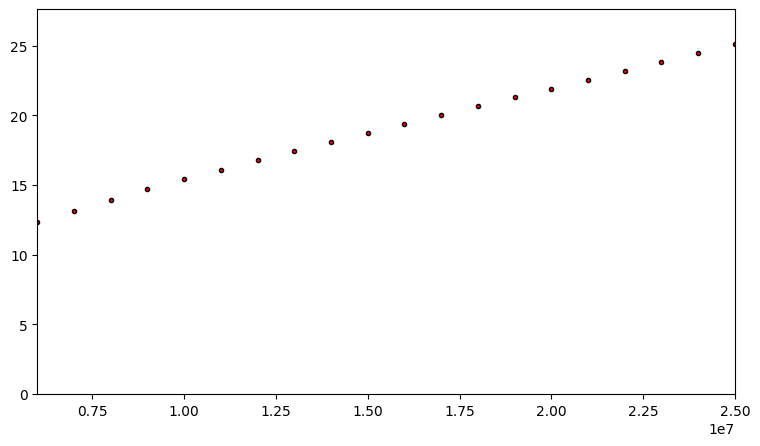

In [103]:
f_Ch1=res2[0]

#phase_diff=ph_diff_cab

phase_diff=res2[2]


fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    f_Ch1,phase_diff,
    marker='o',         # square markers
    markersize=3,
    markerfacecolor='red',
    markeredgecolor='black',
    linestyle='None'    # disables line
)

# ax.plot(
#     f_Ch1,res1[2],
#     marker='o',         # square markers
#     markersize=3,
#     markerfacecolor='red',
#     markeredgecolor='black',
#     linestyle='None'    # disables line
# )
    
ax.set_xlim(np.min(f_Ch1),np.max(f_Ch1))
ax.set_ylim(0,np.max(phase_diff)+0.1*np.max(phase_diff))
#plt.title(f"Power Stability\n Mean={mean:.2f} Std={std:.2f}")
plt.show()

In [59]:
laser.laser_OFF()

'1'

In [60]:
client.close()

In [61]:
gen.close()

In [12]:
freqs=np.linspace(5e6,25e6,101)
gen.output_off(1)

def freq_generator():
    for f in freqs:
        gen.set_waveform(ch=1, wave="SIN", freq_hz=f, ampl_vpp=Vpp_Ch1, offset_v=0.0)
        yield float(f)


client.reset_unwrap()
gen.output_on(1)
rows = client.sweep_phase_vs_frequency_external(
    freq_generator(),
    settle_s=5,
    samples_per_point=30,
    mode="both",                 # wrapped/unwrapped/raw all recorded
    set_pll_to_frequency=True,   # recommended: keep PLL centered on AWG freq
    reacquire_each_step=True,
    reset_unwrap=False
)


gen.output_off(1)

In [98]:
rows

[{'frequency_hz': 6000000.0,
  'delta_phi_wrapped_deg': 12.313458323478699,
  'delta_phi_unwrapped_deg': 12.313458323478699,
  'delta_phi_raw_deg': 12.313458323478699},
 {'frequency_hz': 7000000.0,
  'delta_phi_wrapped_deg': 13.156844079494476,
  'delta_phi_unwrapped_deg': 13.156844079494476,
  'delta_phi_raw_deg': 13.156844079494476},
 {'frequency_hz': 8000000.0,
  'delta_phi_wrapped_deg': 13.944936096668243,
  'delta_phi_unwrapped_deg': 13.944936096668243,
  'delta_phi_raw_deg': 13.944936096668243},
 {'frequency_hz': 9000000.0,
  'delta_phi_wrapped_deg': 14.68945026397705,
  'delta_phi_unwrapped_deg': 14.68945026397705,
  'delta_phi_raw_deg': 14.68945026397705},
 {'frequency_hz': 10000000.0,
  'delta_phi_wrapped_deg': 15.403711795806885,
  'delta_phi_unwrapped_deg': 15.403711795806885,
  'delta_phi_raw_deg': 15.403711795806885},
 {'frequency_hz': 11000000.0,
  'delta_phi_wrapped_deg': 16.09525501728058,
  'delta_phi_unwrapped_deg': 16.09525501728058,
  'delta_phi_raw_deg': 16.0952550

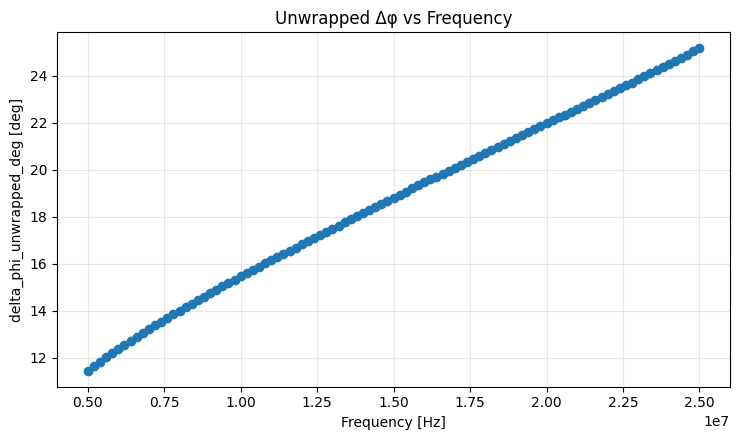

In [13]:
client.plot_sweep(rows, y_key="delta_phi_unwrapped_deg", title="Unwrapped Δφ vs Frequency")